Lab 1: week of September 14
*  claim a dataset
*  exploratory analysis
*  define target, frequency, and horizon

Claimed dataset is "Bike Sharing Capital"


In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

#Data Loading
Our dataset is called Bike Sharing and contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information. It consists of 13 features and 17389 rows. The features are either integers or real numbers.

In [ ]:
#load dataset and show the first 5 rows
df = pd.read_csv('day.csv')
df.head()



FileNotFoundError: [Errno 2] No such file or directory: 'day.csv'

In [ ]:
df2 = pd.read_csv('hour.csv')
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


We have a decision to make: do we use the hourly dataset or the day dataset?
After plotting both, hourly data is very dense. It is hard to see patterns. It would need to be resampled anyway. Maybe our resampling rule should be "go with day to day" rather than hourly.

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Actually need to verify is any value is missing.
We have a regular index.

Great news: there are no missing values.
However, there is a large difference in # of rows depending on if we choose to include hr data or not.

Below is code to get a column called date of datetime type. Datetime objects are python objects that contain all the information of both a date object and a time object. Year, month, day are necessary and hr is the most amount of time data we have.

In [ ]:
#.astype() casts argument to a specified dtype
# therefore, hr goes from numeric to string type before being added to datetime object
df2['date'] = pd.to_datetime(df2['dteday'] + ' ' + df2['hr'].astype(str) + ':00:00')
#df2['date'] = pd.to_datetime(df2['dteday'])
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
date,,,,,,,,,,,,,,,,,,
2011-01-01,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011-01-01 00:00:00
2011-01-01,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011-01-01 01:00:00
2011-01-01,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011-01-01 02:00:00
2011-01-01,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011-01-01 03:00:00
2011-01-01,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011-01-01 04:00:00


In [ ]:
# explore statistics of data
df2.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,2012-01-02 15:41:22.858622464
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2011-01-01 00:00:00
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,2011-07-04 22:30:00
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,2012-01-02 21:00:00
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,2012-07-02 06:30:00
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,2012-12-31 23:00:00
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599,NaN


Descriptive statistics show no missing values.

A lot of these columns are categorical though.

In [ ]:
# make another version of df where date is the index
df2 = df2.set_index('date')

Now the head will show date as the index

In [ ]:
df2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
date,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Below is a plot of this data so we can visualize it raw.

In [ ]:
cnt_data = df2['cnt']
cnt_data.head()

,cnt
date,
2011-01-01 00:00:00,16
2011-01-01 01:00:00,40
2011-01-01 02:00:00,32
2011-01-01 03:00:00,13
2011-01-01 04:00:00,1


<Axes: xlabel='date', ylabel='cnt'>

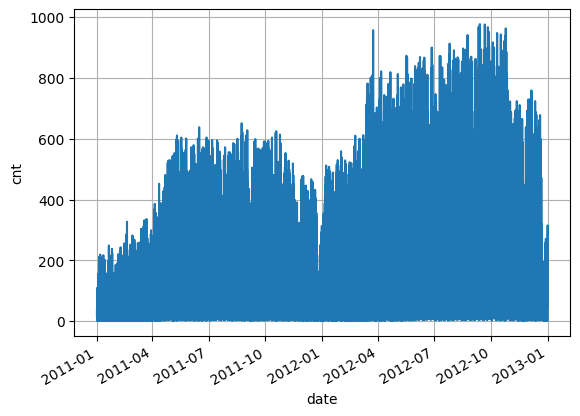

In [ ]:
cnt_data.plot(ylabel='cnt',grid=True)

<Axes: xlabel='date', ylabel='cnt'>

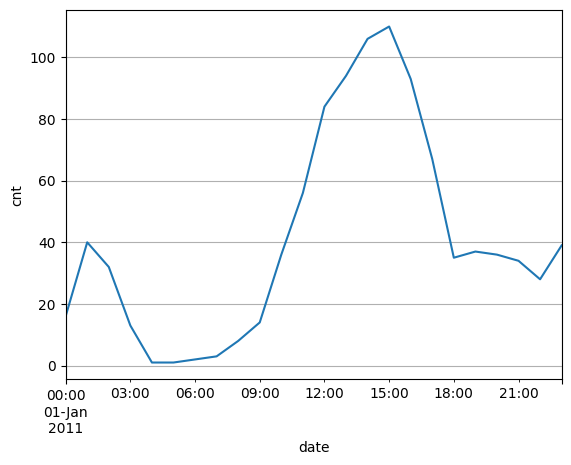

In [ ]:
df2_2011 = df2.loc['2011-01-01']
cnt_data_2011 = df2_2011['cnt']
cnt_data_2011.plot(ylabel='cnt',grid=True)

<Axes: xlabel='date', ylabel='cnt'>

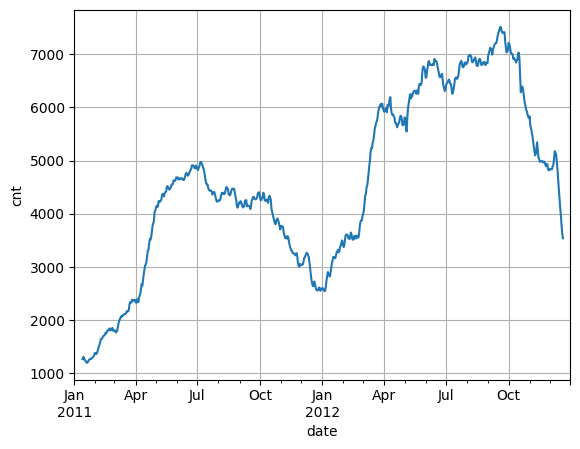

In [ ]:
#use a simple rolling 24 average transformation to see trend and seasonality
from numpy.strings import center
trend_24 = cnt_data.rolling(24, center=True).mean()

fig, ax = plt.subplots(figsize=(11,3.3))
cnt_data.plot(ax=ax, label='Daily')
trend_24.plot(ax=ax, label='24-day moving avg',grid=True)

Need to decide on a look back horizon before modelling.

**What is our target?** how far into the future

**What will our input be?** how far into the past will we use?

Once we decide L and h we can determine our windows.

**What is our forecasting goal?** what questions do we want to be able to answer with our forecasting tool? Predict number of users next year? or predict number of users on a rainy day?

Summary of Dataset
*   it is multivariate
*   sampling is regular, each day. no missed values bc of the sensors.
*   there is seasonality
*   List item

Questions:
*  can we use categorical data?
*   List item





